In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from scipy.ndimage import gaussian_filter, rotate, shift 


# 1) Chargement et préparation de MNIST (SANS BUG)

In [6]:
# 1) Chargement et préparation de MNIST (SANS BUG)


# Chargement MNIST
X, y = fetch_openml("mnist_784", version=1, return_X_y=True)

# Conversion CRUCIALE
X = np.asarray(X, dtype=np.float32)
y = np.asarray(y, dtype=np.int64)

# Normalisation
X /= 255.0

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)


(56000, 784) (14000, 784)


# 2) Entraînement des modèles (données propres)

In [7]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    max_iter=20,
    random_state=42
)

svm = SVC(kernel="rbf", gamma="scale")

mlp.fit(X_train, y_train)
svm.fit(X_train, y_train)

print("Accuracy MLP (clean):", accuracy_score(y_test, mlp.predict(X_test)))
print("Accuracy SVM (clean):", accuracy_score(y_test, svm.predict(X_test)))


C:\Users\loutf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy MLP (clean): 0.9744285714285714
Accuracy SVM (clean): 0.9764285714285714


# 3) Fonctions de corruption

In [10]:
def gaussian_noise(X, sigma):
    noise = np.random.normal(0, sigma, X.shape)
    return np.clip(X + noise, 0, 1)

def blur(X, sigma):
    return np.array([
        gaussian_filter(x.reshape(28,28), sigma).flatten()
        for x in X
    ])

def rotation(X, angle):
    return np.array([
        rotate(x.reshape(28,28), angle, reshape=False, mode="nearest").flatten()
        for x in X
    ])

def translation(X, pixels):
    return np.array([
        shift(x.reshape(28,28), shift=(pixels, pixels), mode="nearest").flatten()
        for x in X
    ])


# 4) Fonction d’évaluation

In [11]:
def evaluate(model, X, y):
    return accuracy_score(y, model.predict(X))


# 5) Exemples de corruptions

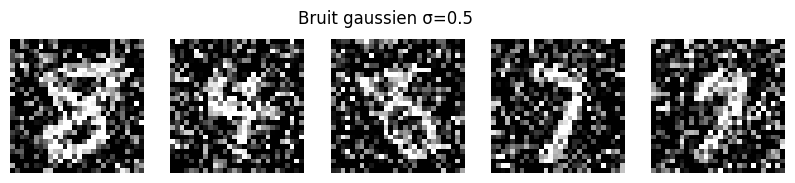

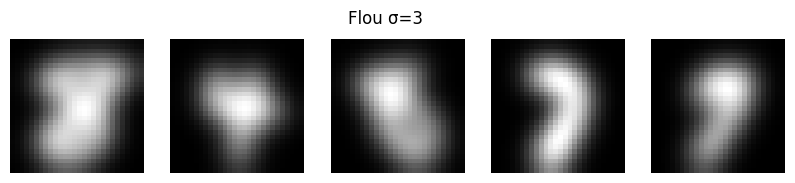

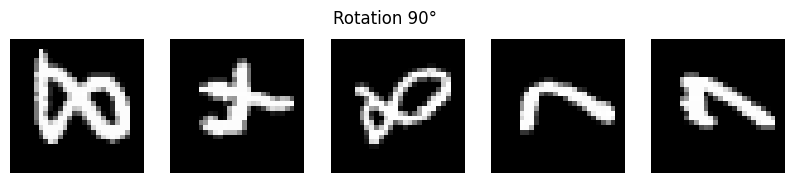

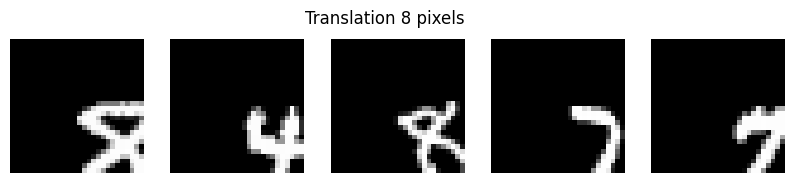

In [12]:
def show_corruptions(X, title):
    plt.figure(figsize=(10,2))
    for i in range(5):
        plt.subplot(1,5,i+1)
        plt.imshow(X[i].reshape(28,28), cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_corruptions(gaussian_noise(X_test, 0.5), "Bruit gaussien σ=0.5")
show_corruptions(blur(X_test, 3), "Flou σ=3")
show_corruptions(rotation(X_test, 90), "Rotation 90°")
show_corruptions(translation(X_test, 8), "Translation 8 pixels")


# 6) Courbes de robustesse

# 6.1) Bruit gaussien

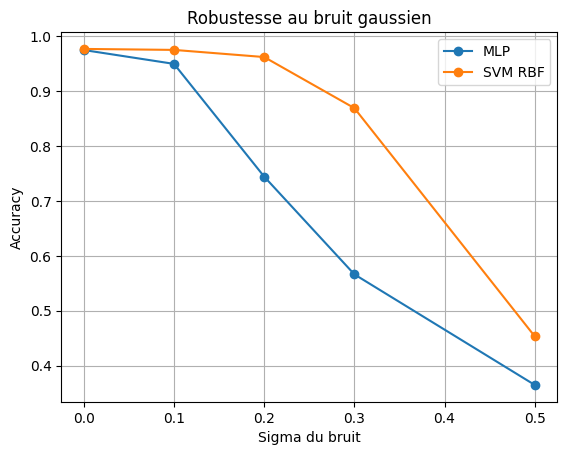

In [14]:
sigmas = [0, 0.1, 0.2, 0.3, 0.5]
acc_mlp, acc_svm = [], []

for s in sigmas:
    Xc = gaussian_noise(X_test, s)
    acc_mlp.append(evaluate(mlp, Xc, y_test))
    acc_svm.append(evaluate(svm, Xc, y_test))

plt.plot(sigmas, acc_mlp, marker="o", label="MLP")
plt.plot(sigmas, acc_svm, marker="o", label="SVM RBF")
plt.xlabel("Sigma du bruit")
plt.ylabel("Accuracy")
plt.title("Robustesse au bruit gaussien")
plt.legend()
plt.grid()
plt.show()


Lorsque l’intensité du bruit augmente, l’accuracy diminue progressivement pour les deux modèles. Toutefois, la chute est plus rapide pour le MLP que pour le SVM, ce qui indique que, dans cette configuration expérimentale, le SVM est moins sensible aux perturbations aléatoires des pixels.

Les résultats montrent ainsi que le SVM RBF est plus robuste au bruit gaussien que le MLP, dont les performances chutent plus rapidement lorsque l’intensité du bruit augmente.

# 6.2) Robustesse au Flou

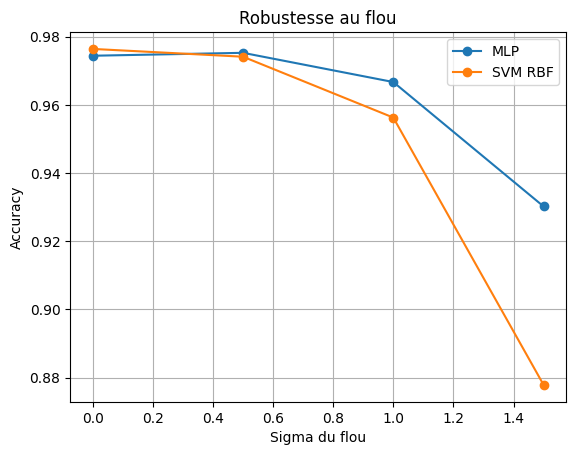

In [15]:
sigmas = [0, 0.5, 1, 1.5]
acc_mlp, acc_svm = [], []

for s in sigmas:
    Xc = blur(X_test, s)
    acc_mlp.append(evaluate(mlp, Xc, y_test))
    acc_svm.append(evaluate(svm, Xc, y_test))

plt.plot(sigmas, acc_mlp, marker="o", label="MLP")
plt.plot(sigmas, acc_svm, marker="o", label="SVM RBF")
plt.xlabel("Sigma du flou")
plt.ylabel("Accuracy")
plt.title("Robustesse au flou")
plt.legend()
plt.grid()
plt.show()


Le flou affecte principalement les contours des chiffres. Le SVM est fortement impacté, tandis que le MLP conserve une meilleure performance, suggérant une meilleure capacité à extraire des caractéristiques globales.

Le flou dégrade les contours des chiffres, ce qui pénalise fortement le SVM. Le MLP, en revanche, conserve une meilleure robustesse face à cette perturbation.

# 6.3) Robustesse à la rotation

In [ ]:
angles = [0, 5, 10, 15]
acc_mlp, acc_svm = [], []

for a in angles:
    Xc = rotation(X_test, a)
    acc_mlp.append(evaluate(mlp, Xc, y_test))
    acc_svm.append(evaluate(svm, Xc, y_test))

plt.plot(angles, acc_mlp, marker="o", label="MLP")
plt.plot(angles, acc_svm, marker="o", label="SVM RBF")
plt.xlabel("Angle (°)")
plt.ylabel("Accuracy")
plt.title("Robustesse à la rotation")
plt.legend()
plt.grid()
plt.show()


La rotation entraîne une diminution progressive des performances pour les deux modèles, ce qui met en évidence un manque d’invariance géométrique. Toutefois, la chute est plus marquée pour le MLP, tandis que le SVM RBF conserve une accuracy plus élevée pour l’ensemble des angles considérés. Cela indique que, dans cette configuration expérimentale, le SVM est plus robuste à la rotation que le MLP.

# 6.4) Robustesse à la translation

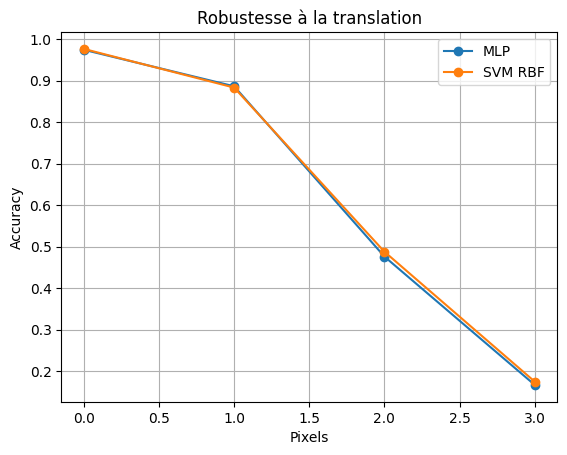

In [ ]:
pixels = [0, 1, 2, 3]
acc_mlp, acc_svm = [], []

for p in pixels:
    Xc = translation(X_test, p)
    acc_mlp.append(evaluate(mlp, Xc, y_test))
    acc_svm.append(evaluate(svm, Xc, y_test))

plt.plot(pixels, acc_mlp, marker="o", label="MLP")
plt.plot(pixels, acc_svm, marker="o", label="SVM RBF")
plt.xlabel("Pixels")
plt.ylabel("Accuracy")
plt.title("Robustesse à la translation")
plt.legend()
plt.grid()
plt.show()


La translation du chiffre entraîne une chute rapide des performances pour les deux modèles. Cette transformation révèle une forte dépendance des modèles à la position absolue des pixels, les deux approches étant fortement pénalisées lorsque le chiffre n’est plus centré. Les performances du MLP et du SVM RBF restent très proches, indiquant une sensibilité comparable à la translation.

# 7) Erreurs typiques

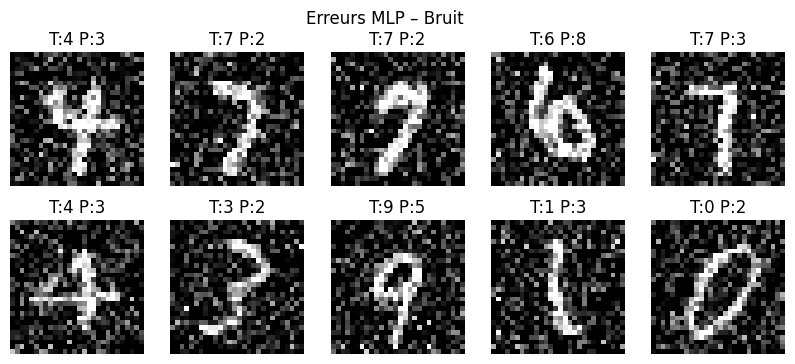

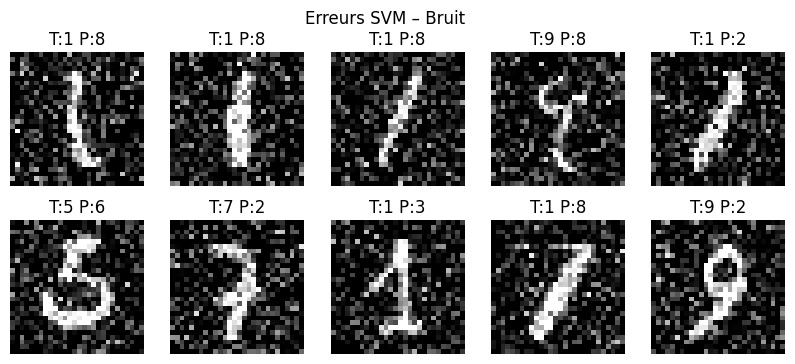

In [11]:
def plot_errors(model, X, y, title):
    pred = model.predict(X)
    errors = np.where(pred != y)[0][:10]

    plt.figure(figsize=(10,4))
    for i, idx in enumerate(errors):
        plt.subplot(2,5,i+1)
        plt.imshow(X[idx].reshape(28,28), cmap="gray")
        plt.title(f"T:{y[idx]} P:{pred[idx]}")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

X_noise = gaussian_noise(X_test, 0.3)
plot_errors(mlp, X_noise, y_test, "Erreurs MLP – Bruit")
plot_errors(svm, X_noise, y_test, "Erreurs SVM – Bruit")


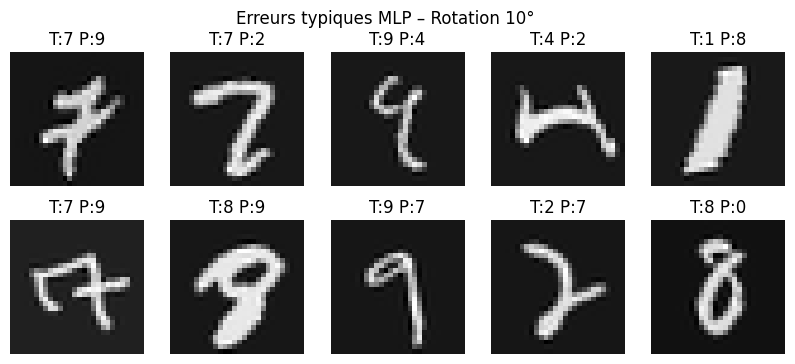

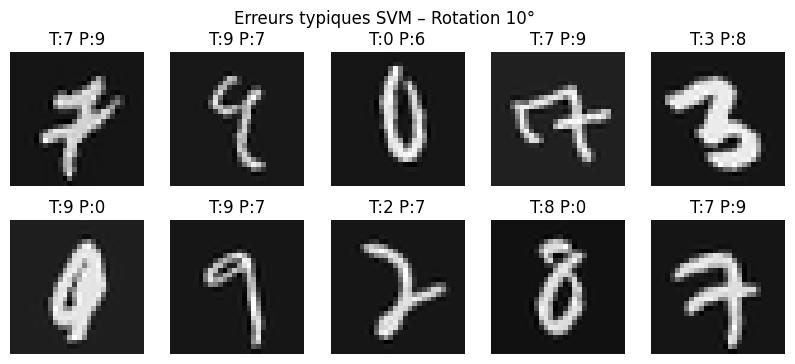

In [14]:
# Données tournées
X_rot = rotation(X_test, angle=10)

# MLP
plot_errors(
    mlp,
    X_rot,
    y_test,
    "Erreurs typiques MLP – Rotation 10°"
)

# SVM
plot_errors(
    svm,
    X_rot,
    y_test,
    "Erreurs typiques SVM – Rotation 10°"
)


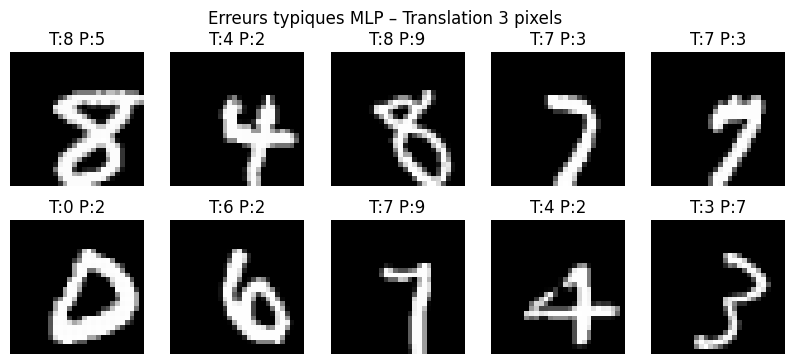

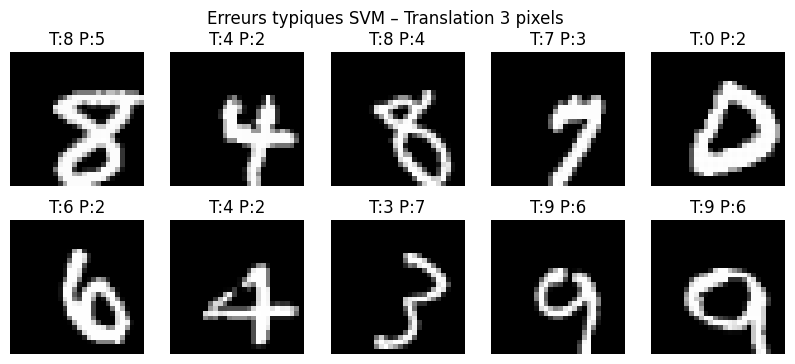

In [15]:
# Données translatées
X_trans = translation(X_test, pixels=3)

# MLP
plot_errors(
    mlp,
    X_trans,
    y_test,
    "Erreurs typiques MLP – Translation 3 pixels"
)

# SVM
plot_errors(
    svm,
    X_trans,
    y_test,
    "Erreurs typiques SVM – Translation 3 pixels"
)


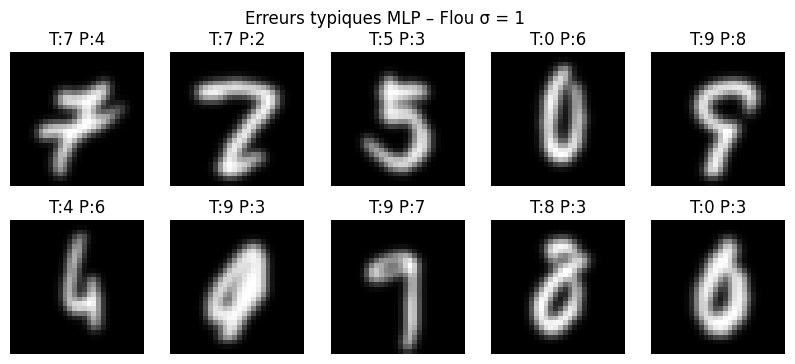

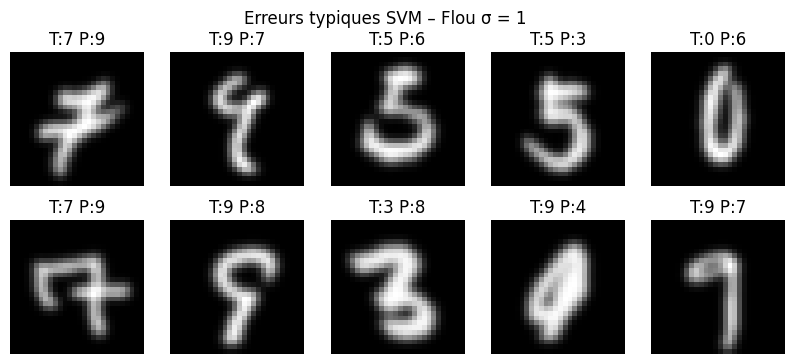

In [35]:
# Données floutées
X_blur = blur(X_test, sigma=1)

# Erreurs MLP
plot_errors(
    mlp,
    X_blur,
    y_test,
    "Erreurs typiques MLP – Flou σ = 1"
)

# Erreurs SVM
plot_errors(
    svm,
    X_blur,
    y_test,
    "Erreurs typiques SVM – Flou σ = 1"
)
